###**Q2 - UNSUPERVISED LEARNING: CUSTOMER SEGMENTATION**

**Task 1: Data Preparation**





In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [16]:
# Load dataset
df = pd.read_csv("q2_customers.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
display(df.head())

# Scale all features
feature_cols = ['age', 'annual_spend', 'visits_per_month',
                'basket_size', 'days_since_last_visit', 'num_categories_purchased']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

# Optional: convert back to DataFrame for readability
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print("\nScaled feature means:")
print(df_scaled.mean().round(4))

print("\nScaled feature standard deviations:")
print(df_scaled.std(ddof=0).round(4))

display(df_scaled.head())

Shape: (500, 6)

Missing values:
 age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



Scaled feature means:
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0
dtype: float64

Scaled feature standard deviations:
age                         1.0
annual_spend                1.0
visits_per_month            1.0
basket_size                 1.0
days_since_last_visit       1.0
num_categories_purchased    1.0
dtype: float64


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


K-means cannot be used directly on the dataset because it works by measuring the distance between different data points. If one attribute has much higher numbers compared to other attributes, then the algorithm will be heavily influenced by that attribute alone, and the clusters created won’t be meaningful. This is where scaling comes in handy, especially using the StandardScaler method.

**Task 2: Choosing K- Elbow Method **

In [17]:
# Compute WCSS for K = 1 to 10

wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Print WCSS values

print(f"{'K':>3}  {'WCSS':>10}")
print("-" * 16)
for k, w in zip(K_range, wcss):
    print(f"{k:>3}  {w:>10.2f}")

  K        WCSS
----------------
  1     3000.00
  2      968.99
  3      561.25
  4      444.93
  5      402.37
  6      370.39
  7      346.95
  8      319.90
  9      303.28
 10      289.11


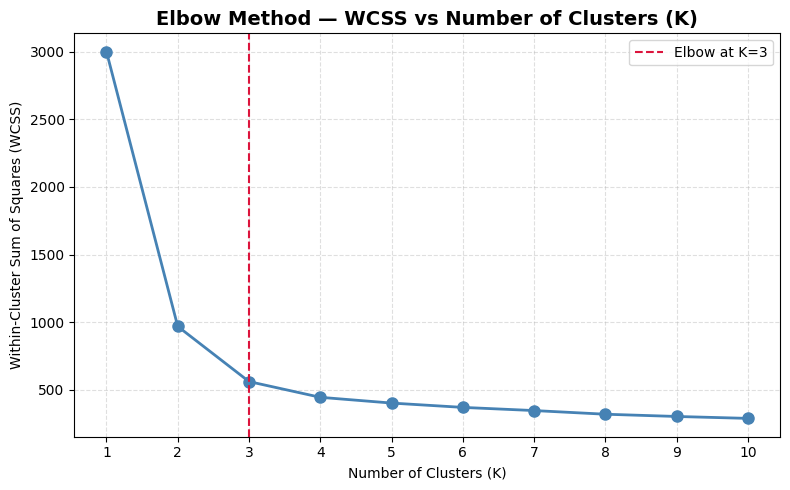

Saved plot_elbow.png


In [18]:
# Elbow plot

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
ax.axvline(x=3, color='crimson', linestyle='--', linewidth=1.5, label='Elbow at K=3')
ax.set_title("Elbow Method — WCSS vs Number of Clusters (K)", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Within-Cluster Sum of Squares (WCSS)")
ax.set_xticks(list(K_range))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("plot_elbow.png", dpi=150)
plt.show()
print("Saved plot_elbow.png")

### Choice of Optimal Value of K – Explanation

In the WCSS chart, there is a sharp decline from K=1 to K=3 followed by an obvious flattening of the line. The elbow occurs at K=3 since the addition of a fourth cluster offers only a slight improvement in WCSS, indicating that it is not worth complicating the model in such a manner.

**The optimal value for K is 3** because it is possible to distinguish three different behavioral clusters within customers in an intuitive way while maintaining a comprehensible model structure for the practical application of business decisions.

**Task 3: K-Means Clustering (K=3)**

In [20]:
# Fit K-Means with K=3

OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)


# Cluster centroids — inverse-transform back to original scale for readability
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=feature_cols,
    index=[f"Cluster {i}" for i in range(OPTIMAL_K)]
).round(2)

print("Cluster Centroids:")
print(centroids_df)


Cluster Centroids:
             age  annual_spend  visits_per_month  basket_size  \
Cluster 0  24.68      14847.37             14.34       558.97   
Cluster 1  56.77      89413.33              2.53      5530.55   
Cluster 2  40.39      43340.73              8.19      2021.68   

           days_since_last_visit  num_categories_purchased  
Cluster 0                   9.08                      2.11  
Cluster 1                 105.36                      7.52  
Cluster 2                  35.19                      4.42  


### Business Interpretation of Clusters




**Cluster 0 - Young, Frequent, and Low Spenders (Casual Browsers)**

- Younger age group (avg. ~25), lowest annual expenditure (avg. ~£14,800), highest visits per month (avg. ~14)
- Small basket size (avg. ~£559), recent purchases (lowest days_since_last_visit ~9 days)
- Fewest categories purchased (avg. ~2)
Visit frequently and browse but purchase less money per visit. Could be students or budget shoppers.
- *Business strategy:* Encourage loyalty through bundling products and cross-selling techniques to expand basket size and category selection.


**Cluster 1 – Older, High Spending, and Low Visiting (High Premium)**

- Older age group (avg. ~57), highest annual expenditure (avg. ~£89,400), fewest visits per month (avg. ~2.5)
- Highest basket size (avg. ~£5,530), fewest visits per day (highest days_since_last_visit ~105 days)
- Highest number of categories purchased (avg. ~7.5)
- Frequent purchases in many categories but rare visits. High value but likely to churn due to non-recency.
*Business strategy*: Personalized outreach efforts, high-tiered membership plans, and exclusive promotions to encourage visit frequency.


**Cluster 2 – Mid-Age, Moderate Spenders (Core Customer Base)**

- Average age (avg. ~40), moderate annual spending (avg. ~£43,300), moderate visit frequency (avg. ~8)
- Moderate basket size (avg. ~£2,020), moderate recency (avg. ~35 days)
Average number of categories purchased (avg. ~4.4)
- A balance between high-spending and frequent purchasing.
*Business strategy*: Retention strategies, personalized recommendations, and subscription services.

**Task 4: Dimentionality Reduction with PCA**

In [21]:
# Apply PCA — reduce to 2 principal components

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

# Feature loadings — how much each original feature contributes to each PC

loadings_df = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=["PC1", "PC2"]
).round(4)

print("\nFeature Loadings:")
print(loadings_df)


Explained Variance Ratio:
PC1: 0.8356 (83.56%)
PC2: 0.0557 (5.57%)

Feature Loadings:
        age  annual_spend  visits_per_month  basket_size  \
PC1  0.4116        0.4215           -0.4104       0.4120   
PC2 -0.2594       -0.0333            0.2083      -0.1954   

     days_since_last_visit  num_categories_purchased  
PC1                 0.3786                    0.4140  
PC2                 0.9112                   -0.1405  


###PC1 and PC2 Interpretation

**PC1 – Value vs. Spending Axis (~83.56% of Variance Explained)**

- PC1 shows positive correlations with annual_spend (0.4215), basket_size (0.4120), num_categories_purchased (0.4140), age (0.4116), and days_since_last_visit (0.3786) variables and negative correlation with visits_per_month (-0.4104).

- High PC1 score = old age, higher spending per year, large basket size, shopping multiple categories, visiting the store less frequently (high value-low frequency customers).

- Low PC1 score = young age, less money spent, fewer purchases per year, small basket size, frequent visits to the shop (low value-high frequency customers).

**PC2 – Recency Axis vs. Visit Behavior Axis (~5.57% of Variance Explained)**

- PC2 strongly correlates with days_since_last_visit (0.9112) variable and less strongly with visits_per_month (0.2083). The PC2 has a negative correlation with age (-0.2594) and basket_size (-0.1954).

- High PC2 score = long time elapsed since last visit to the store (high value = churn risk), irrelevant of how often and how much clients spend at the shop.

- Low PC2 score = shorter time elapsed since clients' visit to the store.

In total, PC1 and PC2 explain ~89% of the variance between customers using 6 features in just 2 dimensions.

**Task 5: Cluster Visualization**

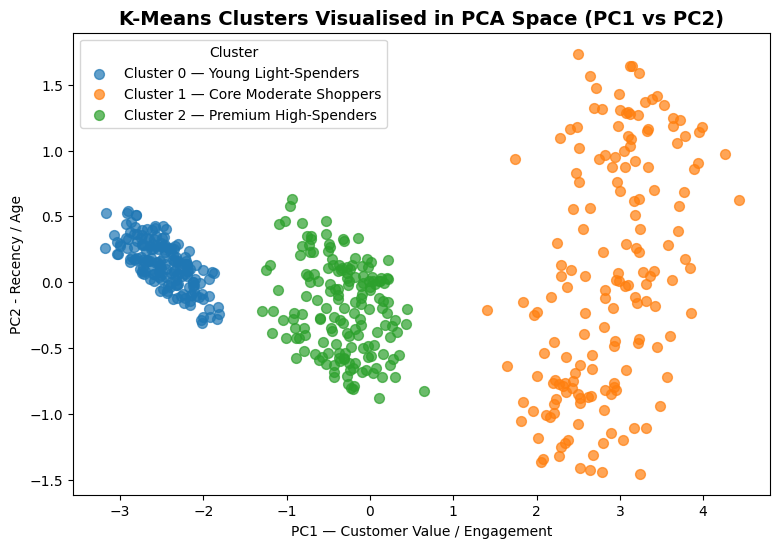

In [28]:
labels  = {0: 'Cluster 0 — Young Light-Spenders',
           1: 'Cluster 1 — Core Moderate Shoppers',
           2: 'Cluster 2 — Premium High-Spenders'}

plt.figure(figsize=(9, 6))

for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=labels[cluster_id],
        alpha=0.7,
        s=50
    )

plt.title("K-Means Clusters Visualised in PCA Space (PC1 vs PC2)",
fontsize=14, fontweight='bold')
plt.xlabel("PC1 — Customer Value / Engagement")
plt.ylabel("PC2 - Recency / Age")
plt.legend(title="Cluster")
plt.show()
